# HVASP with IGS-BRKGA

Demonstrates **IGS-BRKGA** (IMAP Genetic Algorithm with Biased Random-Key encoding) on a synthetic **Heterogeneous Vessel Allocation and Scheduling Problem (HVASP)** instance.

Four objectives are **minimised** simultaneously:

| Objective | Meaning |
|-----------|---------|
| `cost` | Total mobilisation + operational cost (USD) |
| `distance` | Total sailing distance (nm) |
| `duration` | Total makespan (days) |
| `fuel` | Total fuel consumed (MT) |

The synthetic instance is produced by `generate_experiments.generate_dataset` and loaded through the standard Excel/JSON loaders. Preference-curve bounds are derived analytically from the model structure using `calculate_proxy_bounds` (no CP solve required).

## 1. Imports

In [1]:
import os
import sys
import json
import time
from pathlib import Path
from datetime import date

import matplotlib.pyplot as plt
import numpy as np

from pymoo.optimize import minimize as pymoo_minimize
from pymoo.termination import get_termination

# ── Resolve project root so src/ and examples/HVASP are on sys.path ───────────
_HERE = Path(os.getcwd())
if (_HERE / "src").exists():
    _ROOT = _HERE
elif (_HERE.parent / "src").exists():
    _ROOT = _HERE.parent
else:
    _ROOT = _HERE.parents[1]

_SRC = _ROOT / "src"
_HVASP = _ROOT / "examples" / "HVASP"

for _p in [str(_ROOT), str(_SRC), str(_HVASP)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

from generate_experiments import generate_dataset
from utils.load_data import load_input_excel_to_json, load_input_json
from logic.scheduling_model import SchedulingModel
from logic.Decoder import Decoder
from optimization.igs_brkga import IGSBRKGA, IGSBRKGAProblem
from utils.helper_functions import calculate_proxy_bounds
from utils.imap_helpers import build_imap_config, make_pref_cv
from components.ga_types import Chromosome

import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
%matplotlib inline

print(f"Project root : {_ROOT}")
print("Imports OK")

Project root : c:\Users\leti\Documents\IGS-BRKGA
Imports OK


## 2. Configuration

Edit the cell below to choose the instance size, decoder strategy, and run budget.

| Parameter | Description |
|-----------|-------------|
| `NUM_VESSELS` | Number of vessels in the fleet |
| `NUM_ACTIVITIES` | Number of project activities to schedule |
| `NUM_LOCATIONS` | Number of port/location records |
| `STRATEGY` | Decoder heuristic (e.g. `"BRKGA-PERMKEY"`, `"BRKGA-STT"`, `"BRKGA-GRASP"`, `"BRKGA-DIRECT"`, `"BRKGA-RCPSP"`, `"BRKGA-RANDOM"`) |
| `N_GEN` | Number of generations |
| `POP_SIZE` | Population size |
| `SEED` | Random seed |

**Stakeholder configuration** — each stakeholder dict accepts:
- `obj_weights` — per-objective weight (must sum to 1, length == 4)
- `weight` — relative importance of this stakeholder
- `pref_shape` — `"linear"` \| `"convex"` \| `"concave"` \| `"sigmoid"`
- `reverse` — if `True`, flips the preference direction (higher objective = better)

In [2]:
# ── Instance generation ──────────────────────────────────────────────────────
INSTANCE_NAME:  str = "HVASP-S-01"   # label for plots / output files
NUM_VESSELS:    int = 6
NUM_ACTIVITIES: int = 10
NUM_LOCATIONS:  int = 6
COMPLEXITY:     str = "low"          # "low" | "medium" | "high"
TIGHTNESS:      str = "loose"        # "loose" | "tight"
OVERLAP_DENSITY:   float = 0.40
MULTI_VESSEL_FRAC: float = 0.30
GEN_SEED:       int = 45             # feasible seed (Small instance)

# ── Decoder ─────────────────────────────────────────────────────────────
STRATEGY: str = "BRKGA-PERMKEY"

# ── Run budget ─────────────────────────────────────────────────────────
N_GEN:    int = 50
POP_SIZE: int = 200
SEED:     int = 42

# ── BRKGA fractions ─────────────────────────────────────────────────────
ELITE_FRACTION:  float = 0.15
MUTANT_FRACTION: float = 0.10
CROSSOVER_BIAS:  float = 0.70

# ── Objectives (alphabetical — must match the algorithm's sorted key order) ─────
OBJ_NAMES = ["cost", "distance", "duration", "fuel"]

# ── Stakeholder configuration (one stakeholder per objective) ────────────────
STAKEHOLDERS: list[dict] = [
    {"obj_weights": [1.0, 0.0, 0.0, 0.0], "weight": 0.25, "pref_shape": "linear"},
    {"obj_weights": [0.0, 1.0, 0.0, 0.0], "weight": 0.25, "pref_shape": "linear"},
    {"obj_weights": [0.0, 0.0, 1.0, 0.0], "weight": 0.25, "pref_shape": "linear"},
    {"obj_weights": [0.0, 0.0, 0.0, 1.0], "weight": 0.25, "pref_shape": "linear"},
]

# ── Paths ────────────────────────────────────────────────────────────
DATE_ORIGIN = date(2026, 1, 1)
_DATA_DIR = _HVASP / "data"
_DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"Instance : {INSTANCE_NAME}  ({NUM_VESSELS} vessels, {NUM_ACTIVITIES} activities)")
print(f"Strategy : {STRATEGY}")
print(f"N_GEN={N_GEN}  POP_SIZE={POP_SIZE}  SEED={SEED}")
print(f"Data dir : {_DATA_DIR}")

Instance : HVASP-S-01  (6 vessels, 10 activities)
Strategy : BRKGA-PERMKEY
N_GEN=50  POP_SIZE=200  SEED=42
Data dir : c:\Users\leti\Documents\IGS-BRKGA\examples\HVASP\data


## 3. Problem Setup

Generate the synthetic HVASP dataset, load it into `Vessel` / `Activity` objects, build the `SchedulingModel` and `Decoder`, and compute analytical upper bounds for every objective via `calculate_proxy_bounds` (instant, no CP solve).

In [3]:
# ── Generate the dataset (Excel + companion current-locations JSON) ──────────
_xlsx = _DATA_DIR / f"{INSTANCE_NAME}.xlsx"
_cur_loc = _DATA_DIR / f"{INSTANCE_NAME}_cur_loc.json"

generate_dataset(
    num_vessels=NUM_VESSELS,
    num_activities=NUM_ACTIVITIES,
    num_locations=NUM_LOCATIONS,
    complexity=COMPLEXITY,
    tightness=TIGHTNESS,
    filename=str(_xlsx),
    random_seed=GEN_SEED,
    overlap_density=OVERLAP_DENSITY,
    multi_vessel_frac=MULTI_VESSEL_FRAC,
    current_locations_path=str(_cur_loc),
)

# ── Load into Vessel / Activity objects ───────────────────────────────────
with open(_cur_loc) as f:
    current_locations = json.load(f)

input_dict, n_v, n_a = load_input_excel_to_json(str(_xlsx), DATE_ORIGIN)
input_dict["current_locations"] = current_locations
vessels, activities = load_input_json(input_dict, DATE_ORIGIN)

print(f"Vessels    : {len(vessels)}")
print(f"Activities : {len(activities)}  "
      f"(tows/maintenance + current-location anchors)")

2026-06-15 14:52:21.484 | INFO     | utils.load_data:load_input_json:143 - Created 6 vessels, 12 projects and maintenance activities and 6 current locations.


Generated Excel : c:\Users\leti\Documents\IGS-BRKGA\examples\HVASP\data\HVASP-S-01.xlsx  (seed=45, cluster=north_sea)
Generated JSON  : c:\Users\leti\Documents\IGS-BRKGA\examples\HVASP\data\HVASP-S-01_cur_loc.json  (6 vessels)
Vessels    : 6
Activities : 18  (tows/maintenance + current-location anchors)


In [4]:
# ── Build the scheduling model and decoder ───────────────────────────────
model   = SchedulingModel(vessels, activities, DATE_ORIGIN)
decoder = Decoder(model, strategy=STRATEGY)
problem = IGSBRKGAProblem(model=model, decoder=decoder)

print(f"Roles      : {model.num_roles}")
print(f"Chromosome : {problem.n_var} genes")
print(f"Objectives : {problem.all_objectives}")
print()

# ── Analytical proxy bounds (worst-case upper bounds, instant) ──────────────
proxy = calculate_proxy_bounds(model)
bounds = {obj: (0.0, float(proxy[obj])) for obj in OBJ_NAMES}

print(f"{'Objective':<12}  {'lo':>14}  {'hi':>14}")
print("-" * 46)
for obj in OBJ_NAMES:
    lo, hi = bounds[obj]
    print(f"{obj:<12}  {lo:>14.2f}  {hi:>14.2f}")

Roles      : 24
Chromosome : 86 genes
Objectives : ['cost', 'distance', 'duration', 'fuel']

Objective                 lo              hi
----------------------------------------------
cost                    0.00     33028200.00
distance                0.00        12456.00
duration                0.00          366.00
fuel                    0.00        27597.00


## 4. Preference Functions

IMAP aggregation converts raw objective values into preference scores in **[0, 100]**, where **higher is better**.

`build_imap_config` constructs the three structures required by `IGSBRKGA`:
- `preference_functions` — per-stakeholder, per-objective callables
- `objective_weights` — per-stakeholder weight per objective
- `stakeholder_weights` — one weight per stakeholder (normalised internally)

A **constraint-violation preference function** (`make_pref_cv`) is also provided so that infeasible solutions (unassigned roles, time-window or travel violations) are always deprioritised.

In [5]:
obj_bounds = [bounds[obj] for obj in OBJ_NAMES]

preference_functions, objective_weights, stakeholder_weights = build_imap_config(
    n_obj=len(OBJ_NAMES),
    obj_bounds=obj_bounds,
    obj_names=OBJ_NAMES,
    stakeholder_configs=STAKEHOLDERS,
)

cv_pref_fn = make_pref_cv()

print(f"{len(STAKEHOLDERS)} stakeholder(s) configured:")
for i, cfg in enumerate(STAKEHOLDERS, 1):
    print(
        f"  [{i}] weight={cfg['weight']:.2f}, obj_weights={cfg['obj_weights']}, "
        f"pref_shape={cfg.get('pref_shape', 'linear')}, "
        f"reverse={cfg.get('reverse', False)}"
    )

4 stakeholder(s) configured:
  [1] weight=0.25, obj_weights=[1.0, 0.0, 0.0, 0.0], pref_shape=linear, reverse=False
  [2] weight=0.25, obj_weights=[0.0, 1.0, 0.0, 0.0], pref_shape=linear, reverse=False
  [3] weight=0.25, obj_weights=[0.0, 0.0, 1.0, 0.0], pref_shape=linear, reverse=False
  [4] weight=0.25, obj_weights=[0.0, 0.0, 0.0, 1.0], pref_shape=linear, reverse=False


### Preference curves

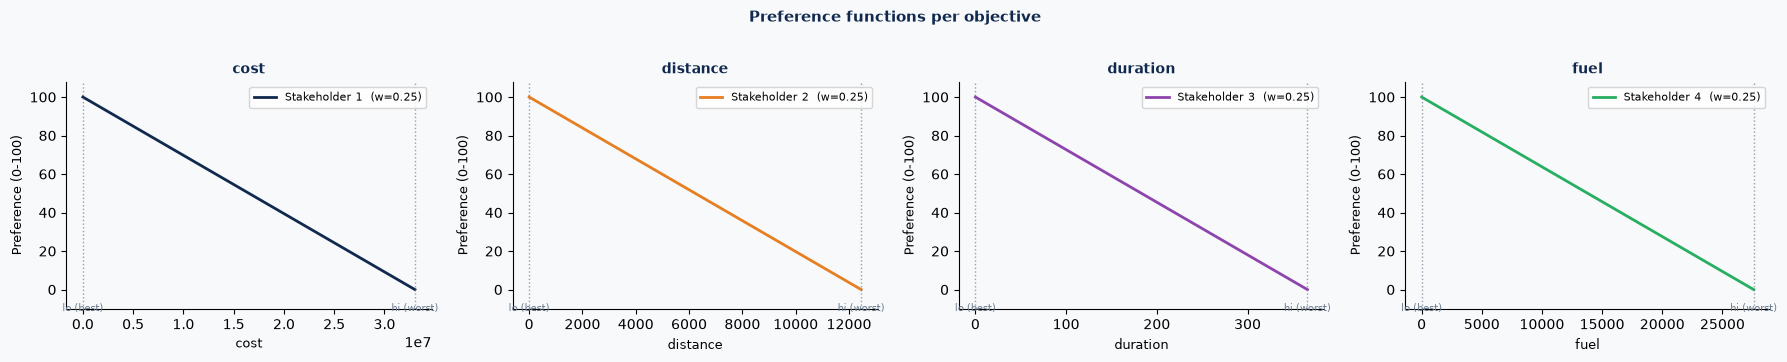

In [7]:
palette = ["#11294e", "#e67e22", "#8e44ad", "#27ae60"]

def _is_reversed(cfg: dict) -> bool:
    """Read the reverse flag from a stakeholder config (tolerates 'reversed' typo)."""
    return cfg.get("reverse", cfg.get("reversed", False))

fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))

for j, (ax, obj) in enumerate(zip(axes, OBJ_NAMES)):
    lo, hi = bounds[obj]
    xs = np.linspace(lo, hi, 300)

    active_cfg = next(
        (cfg for cfg in STAKEHOLDERS if cfg["obj_weights"][j] != 0.0), None
    )
    is_rev = _is_reversed(active_cfg) if active_cfg else False
    lo_label = "lo (worst)" if is_rev else "lo (best)"
    hi_label = "hi (best)"  if is_rev else "hi (worst)"

    for sid, cfg in enumerate(STAKEHOLDERS, 1):
        if cfg["obj_weights"][j] == 0.0:
            continue
        pf_fn = preference_functions[sid][obj]
        ys = [pf_fn(x) for x in xs]
        ax.plot(xs, ys, color=palette[(sid - 1) % len(palette)], linewidth=2,
                label=f"Stakeholder {sid}  (w={cfg['weight']:.2f})")

    for x_bound, lbl in [(lo, lo_label), (hi, hi_label)]:
        ax.axvline(x_bound, color="#6b7a8d", linestyle=":", linewidth=1, alpha=0.7)
        ax.text(x_bound, -7, lbl, ha="center", va="top", fontsize=7, color="#6b7a8d")

    ax.set_xlabel(obj, fontsize=9)
    ax.set_ylabel("Preference (0-100)", fontsize=9)
    ax.set_title(f"{obj}", fontsize=10, fontweight="bold", color="#11294e")
    ax.set_ylim(-10, 108)
    ax.legend(fontsize=8, loc="upper right")
    ax.set_facecolor("#f7f9fb")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "Preference functions per objective",
    fontsize=11, fontweight="bold", color="#11294e", y=1.02,
)
fig.patch.set_facecolor("#f7f9fb")
fig.tight_layout()
plt.show()

## 5. Run IGS-BRKGA

Configure and run **IGS-BRKGA** on the HVASP problem.

Key parameters:
- `pop_size` — population size per generation
- `elite_fraction` — fraction kept as elite (inherits from BRKGA)
- `mutant_fraction` — fraction replaced by random immigrants
- `crossover_bias` — probability of inheriting from the elite parent
- `cv_pref_fn` / `cv_weight` — give 50 % of the aggregation weight to feasibility, so solutions that violate the scheduling constraints are always dominated by feasible ones

In [8]:
algorithm = IGSBRKGA(
    preference_functions=preference_functions,
    objective_weights=objective_weights,
    stakeholder_weights=stakeholder_weights,
    pop_size=POP_SIZE,
    elite_fraction=ELITE_FRACTION,
    mutant_fraction=MUTANT_FRACTION,
    crossover_bias=CROSSOVER_BIAS,
    cv_pref_fn=cv_pref_fn,
    cv_weight=0.5,
    verbose=True,
    seed=SEED,
)

t0 = time.perf_counter()
res = pymoo_minimize(
    problem,
    algorithm,
    get_termination("n_gen", N_GEN),
    seed=SEED,
    verbose=False,
    copy_algorithm=False,
)
wall_time = time.perf_counter() - t0

print(f"\nOptimisation complete in {wall_time:.1f}s")
print(f"Best solution found at generation : {res.algorithm.current_best_gen}")


Optimisation complete in 11.3s
Best solution found at generation : 49


In [9]:
# ── Extract best solution ────────────────────────────────────────────────
best = res.algorithm.current_best
best_F = best.get("F").flatten()
best_G = best.get("G").flatten()
cv = float(np.sum(np.maximum(0.0, best_G)))

# problem.all_objectives order: ['cost', 'distance', 'duration', 'fuel']
best_cost, best_distance, best_duration, best_fuel = best_F
imap_score = float(best.get("imap_score"))

print(f"Best cost          : {best_cost:,.0f} USD")
print(f"Best distance      : {best_distance:,.1f} nm")
print(f"Best duration      : {best_duration:.0f} days")
print(f"Best fuel          : {best_fuel:,.1f} MT")
print(f"Constraint penalty : {cv:.2f}  "
      f"{'✓ feasible' if cv <= 1e-6 else '✗ infeasible'}")
print(f"IMAP score         : {imap_score:.2f}")

# ── Decode the chromosome to recover the schedule ──────────────────────────
_flat = best.get("X").flatten()
_chrom = Chromosome(
    id=0,
    start_time_keys=_flat[problem._s0:problem._s1],
    role_priority_keys=_flat[problem._s1:problem._s2],
    location_keys=_flat[problem._s2:problem._s3],
    speed_keys=_flat[problem._s3:problem._s4],
    start_window_keys=_flat[problem._s4:problem._s5],
)
best_sol = decoder.decode(_chrom)

print(f"\nVessel assignments ({model.num_vessels} vessels):")
for v_idx, seq in enumerate(best_sol.vessel_sequences):
    names = [model.activities[a].activity_name for a in seq]
    print(f"  {vessels[v_idx].vessel_name:<22}: {names if names else '— idle —'}")

Best cost          : 21,935,700 USD
Best distance      : 2,507.5 nm
Best duration      : 270 days
Best fuel          : 254.0 MT
Constraint penalty : 0.00  ✓ feasible
IMAP score         : 100.00

Vessel assignments (6 vessels):
  Vessel 1              : ['Current Location - Vessel 1', 'Synthetic Operation 6', 'Synthetic Operation 7', 'Synthetic Operation 2']
  Vessel 2              : ['Current Location - Vessel 2', 'Synthetic Operation 4', 'Synthetic Operation 1']
  Vessel 3              : ['Current Location - Vessel 3', 'Synthetic Operation 9', 'Synthetic Operation 5', 'Synthetic Operation 10']
  Vessel 4              : ['Current Location - Vessel 4', 'Synthetic Operation 4', 'Synthetic Operation 8']
  Vessel 5              : ['Current Location - Vessel 5', 'Synthetic Operation 6', 'Synthetic Operation 8', 'Synthetic Operation 3', 'Synthetic Operation 10', 'Dry Dock Vessel 5_Vessel 5']
  Vessel 6              : ['Current Location - Vessel 6', 'Synthetic Operation 6', 'Dry Dock Vessel 6

## 6. Results

### 6a. Hall-of-fame convergence

Each entry in the hall-of-fame is a solution that was IMAP-preferred at some point during the run. Tracking it shows how the algorithm improved over generations.

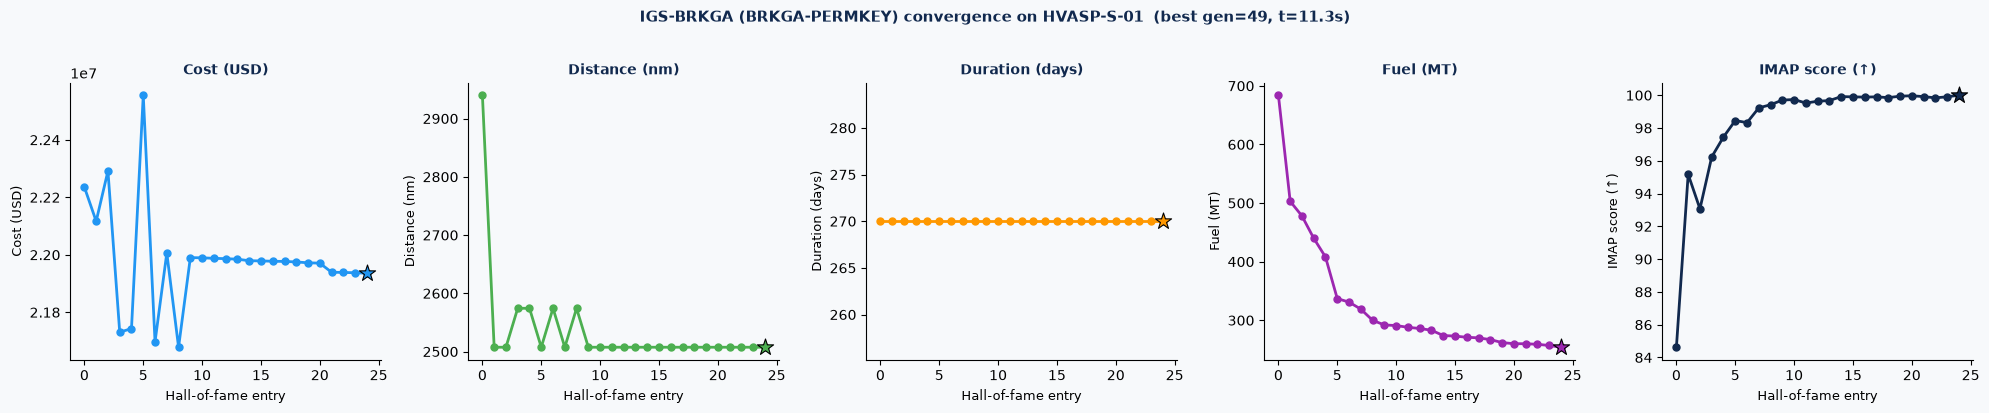

In [10]:
hof = res.algorithm.hall_of_fame  # list[Individual]

if hof:
    hof_F      = np.array([ind.get("F").flatten() for ind in hof])
    hof_scores = np.array([float(ind.get("imap_score")) for ind in hof])
else:
    hof_F      = np.empty((0, len(OBJ_NAMES)))
    hof_scores = np.empty(0)

cb_F     = best_F.reshape(1, len(OBJ_NAMES))
cb_score = np.array([imap_score])
all_F      = np.vstack([hof_F, cb_F]) if len(hof_F) else cb_F
all_scores = np.append(hof_scores, cb_score)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
obj_labels = ["Cost (USD)", "Distance (nm)", "Duration (days)", "Fuel (MT)", "IMAP score (↑)"]
colors = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0", "#11294e"]
series = [all_F[:, 0], all_F[:, 1], all_F[:, 2], all_F[:, 3], all_scores]

for ax, vals, label, color in zip(axes, series, obj_labels, colors):
    xs = range(len(vals))
    ax.plot(xs, vals, color=color, linewidth=2, marker="o", markersize=5)
    ax.scatter([len(vals) - 1], [vals[-1]], s=150, color=color, marker="*",
               edgecolors="black", linewidths=0.8, zorder=5)
    ax.set_xlabel("Hall-of-fame entry", fontsize=9)
    ax.set_ylabel(label, fontsize=9)
    ax.set_title(label, fontsize=10, fontweight="bold", color="#11294e")
    ax.set_facecolor("#f7f9fb")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    f"IGS-BRKGA ({STRATEGY}) convergence on {INSTANCE_NAME}  "
    f"(best gen={res.algorithm.current_best_gen}, t={wall_time:.1f}s)",
    fontsize=11, fontweight="bold", color="#11294e", y=1.02,
)
fig.patch.set_facecolor("#f7f9fb")
fig.tight_layout()
plt.show()

### 6b. Best schedule (Gantt)

Each row is a vessel; each bar is a scheduled activity positioned by its decoded start day and duration. Current-location anchors (duration 0) are omitted.

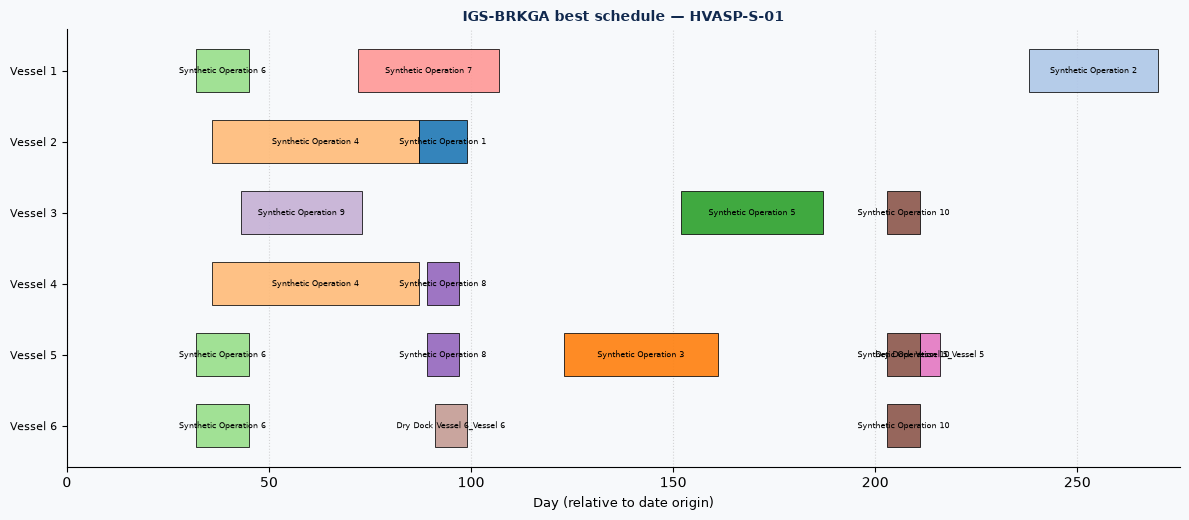

In [13]:
n_vessels = model.num_vessels
cmap = plt.get_cmap("tab20", max(model.num_activities, 1))

fig, ax = plt.subplots(figsize=(12, 0.55 * n_vessels + 2))

max_end = 1
for v_idx, seq in enumerate(best_sol.vessel_sequences):
    for a_idx in seq:
        act = model.activities[a_idx]
        dur = int(getattr(act, "duration", 0) or 0)
        if dur <= 0:
            continue
        start = float(best_sol.start_times[a_idx])
        ax.barh(v_idx, dur, left=start, height=0.6,
                color=cmap(a_idx % cmap.N), edgecolor="black", linewidth=0.6,
                alpha=0.9, zorder=3)
        ax.text(start + dur / 2, v_idx, act.activity_name,
                ha="center", va="center", fontsize=6, color="black", zorder=4)
        max_end = max(max_end, start + dur)

ax.set_yticks(range(n_vessels))
ax.set_yticklabels([v.vessel_name for v in vessels], fontsize=8)
ax.set_xlabel("Day (relative to date origin)", fontsize=9)
ax.set_xlim(0, max_end * 1.02)
ax.set_title(
    f"IGS-BRKGA best schedule — {INSTANCE_NAME}",
    # f"cost={best_cost:,.0f}  |  duration={best_duration:.0f}d  |  fuel={best_fuel:,.0f}MT",
    fontsize=10, fontweight="bold", color="#11294e",
)
ax.grid(axis="x", linestyle=":", alpha=0.5, zorder=0)
ax.set_facecolor("#f7f9fb")
ax.spines[["top", "right"]].set_visible(False)
ax.invert_yaxis()
fig.patch.set_facecolor("#f7f9fb")
fig.tight_layout()
plt.show()

### 6c. Preference scores

For each objective, the configured preference curves are plotted over the full bounds range. The ★ marks where the IMAP-selected best solution falls on each stakeholder's curve.

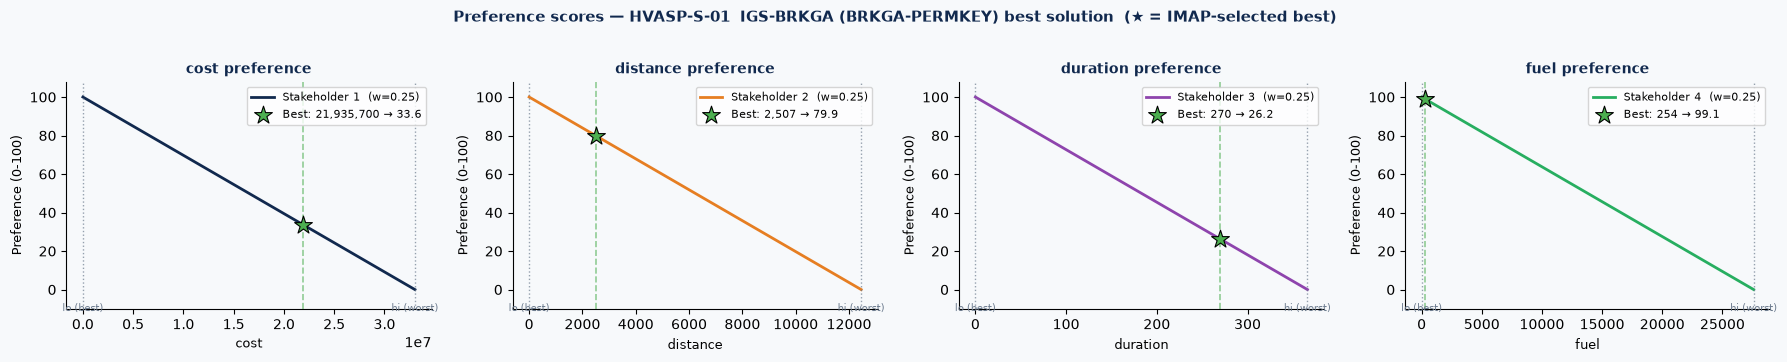


Per-stakeholder preference summary for the best solution:
  Stakeholder 1: cost=33.6, distance=79.9, duration=26.2, fuel=99.1  →  weighted=33.6
  Stakeholder 2: cost=33.6, distance=79.9, duration=26.2, fuel=99.1  →  weighted=79.9
  Stakeholder 3: cost=33.6, distance=79.9, duration=26.2, fuel=99.1  →  weighted=26.2
  Stakeholder 4: cost=33.6, distance=79.9, duration=26.2, fuel=99.1  →  weighted=99.1

  IMAP score (pool-relative): 100.00


In [14]:
stake_palette = ["#11294e", "#e67e22", "#8e44ad", "#27ae60"]
raw_vals = [best_cost, best_distance, best_duration, best_fuel]

fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))

for j, (ax, obj, raw_val) in enumerate(zip(axes, OBJ_NAMES, raw_vals)):
    lo, hi = bounds[obj]
    xs = np.linspace(lo, hi, 300)

    active_sid = next(
        (sid for sid, cfg in enumerate(STAKEHOLDERS, 1) if cfg["obj_weights"][j] != 0.0),
        1,
    )
    active_cfg = STAKEHOLDERS[active_sid - 1]
    is_rev = _is_reversed(active_cfg)
    lo_label = "lo (worst)" if is_rev else "lo (best)"
    hi_label = "hi (best)"  if is_rev else "hi (worst)"

    for sid, cfg in enumerate(STAKEHOLDERS, 1):
        if cfg["obj_weights"][j] == 0.0:
            continue
        pf_fn = preference_functions[sid][obj]
        ys = [pf_fn(x) for x in xs]
        ax.plot(xs, ys, color=stake_palette[(sid - 1) % len(stake_palette)],
                linewidth=2, label=f"Stakeholder {sid}  (w={cfg['weight']:.2f})")

    best_pref = preference_functions[active_sid][obj](float(raw_val))
    ax.scatter([raw_val], [best_pref], s=180, color="#4CAF50", marker="*",
               edgecolors="black", linewidths=0.8, zorder=5,
               label=f"Best: {raw_val:,.0f} → {best_pref:.1f}")
    ax.axvline(raw_val, color="#4CAF50", linestyle="--", linewidth=1.2,
               alpha=0.6, zorder=3)

    for x_bound, lbl in [(lo, lo_label), (hi, hi_label)]:
        ax.axvline(x_bound, color="#6b7a8d", linestyle=":", linewidth=1, alpha=0.7)
        ax.text(x_bound, -7, lbl, ha="center", va="top", fontsize=7, color="#6b7a8d")

    ax.set_xlabel(obj, fontsize=9)
    ax.set_ylabel("Preference (0-100)", fontsize=9)
    ax.set_title(f"{obj} preference", fontsize=10, fontweight="bold", color="#11294e")
    ax.set_ylim(-10, 108)
    ax.legend(fontsize=8, loc="upper right")
    ax.set_facecolor("#f7f9fb")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    f"Preference scores — {INSTANCE_NAME}  IGS-BRKGA ({STRATEGY}) best solution  (★ = IMAP-selected best)",
    fontsize=11, fontweight="bold", color="#11294e", y=1.02,
)
fig.patch.set_facecolor("#f7f9fb")
fig.tight_layout()
plt.show()

print("\nPer-stakeholder preference summary for the best solution:")
for sid, cfg in enumerate(STAKEHOLDERS, 1):
    scores = [preference_functions[sid][obj](float(v))
              for obj, v in zip(OBJ_NAMES, raw_vals)]
    weighted = sum(w * s for w, s in zip(cfg["obj_weights"], scores))
    print(f"  Stakeholder {sid}: " +
          ", ".join(f"{obj}={s:.1f}" for obj, s in zip(OBJ_NAMES, scores)) +
          f"  →  weighted={weighted:.1f}")
print(f"\n  IMAP score (pool-relative): {imap_score:.2f}")